<a href="https://colab.research.google.com/github/alissongurgel8/Impact/blob/main/Impact3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear entre inflação e ipca

In [1]:
!pip install python-bcb

                            OLS Regression Results                            
Dep. Variable:         VAR_DESEMPREGO   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     5.345
Date:                Thu, 13 Aug 2026   Prob (F-statistic):             0.0223
Time:                        19:48:35   Log-Likelihood:                -34.326
No. Observations:                 136   AIC:                             72.65
Df Residuals:                     134   BIC:                             78.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0123      0.027     -0.456      0.6

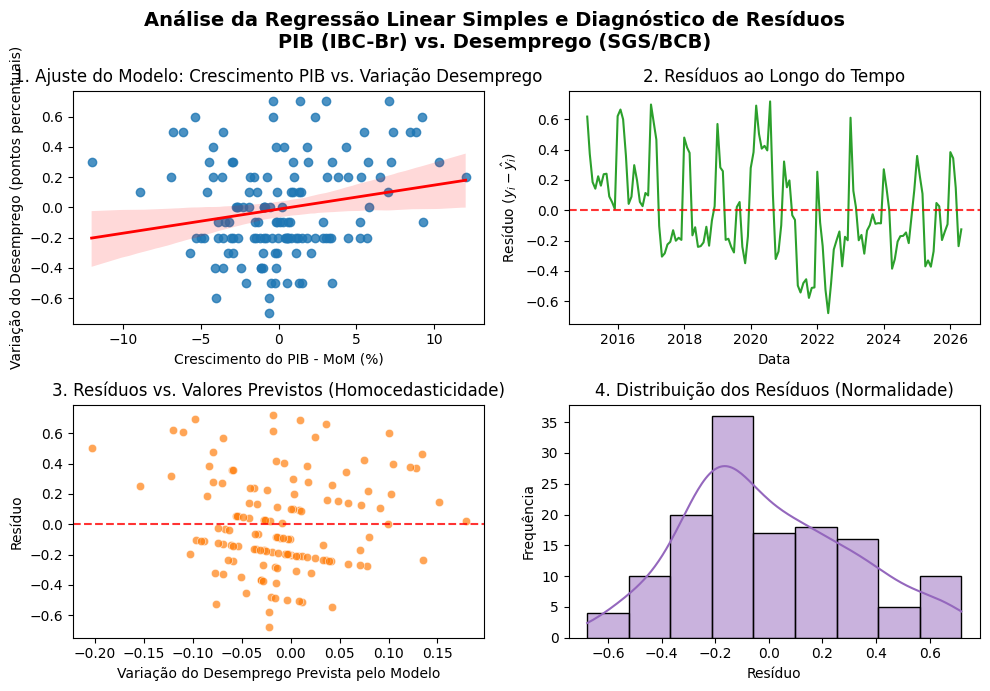

In [10]:
from bcb import sgs
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns

# 1. Coleta dos Dados no SGS/BCB
# 24369 = Taxa de desocupação (PNADC/IBGE) (%)
# 24363 = IBC-Br - Índice de Atividade Econômica do BCB (Dessazonalizado)
dados = sgs.get({"DESEMPREGO": 24369, "IBC_BR": 24363}, start="2015-01-01")
dados = dados.dropna()

# 2. Transformações para garantir estacionariedade
# X = Crescimento do PIB/IBC-Br em % (mês a mês)
dados["CRESC_PIB"] = dados["IBC_BR"].pct_change() * 100

# Y = Variação em pontos percentuais da taxa de desemprego
dados["VAR_DESEMPREGO"] = dados["DESEMPREGO"].diff()

dados = dados.dropna()

# 3. Definição das variáveis
Y = dados["VAR_DESEMPREGO"]
X = sm.add_constant(dados["CRESC_PIB"])

# 4. Ajuste do Modelo OLS
modelo = sm.OLS(Y, X).fit()

print(modelo.summary())

# Captura de ajustados e resíduos
dados['valores_ajustados'] = modelo.fittedvalues
dados['residuos'] = modelo.resid

# 5. Geração dos Gráficos
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Análise da Regressão Linear Simples e Diagnóstico de Resíduos\nPIB (IBC-Br) vs. Desemprego (SGS/BCB)", fontsize=14, fontweight='bold')

# Gráfico 1: Dispersão e Reta de Regressão (CORRIGIDO)
sns.regplot(
    x='CRESC_PIB',
    y='VAR_DESEMPREGO',
    data=dados,
    ax=axes[0, 0],
    color='#1f77b4',
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[0, 0].set_title("1. Ajuste do Modelo: Crescimento PIB vs. Variação Desemprego")
axes[0, 0].set_xlabel("Crescimento do PIB - MoM (%)")
axes[0, 0].set_ylabel("Variação do Desemprego (pontos percentuais)")

# Gráfico 2: Série Temporal dos Resíduos
axes[0, 1].plot(dados.index, dados['residuos'], color='#2ca02c', linewidth=1.5)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.8)
axes[0, 1].set_title("2. Resíduos ao Longo do Tempo")
axes[0, 1].set_xlabel("Data")
axes[0, 1].set_ylabel("Resíduo ($y_i - \\hat{y}_i$)")

# Gráfico 3: Resíduos vs. Valores Ajustados (Homocedasticidade)
sns.scatterplot(x='valores_ajustados', y='residuos', data=dados, ax=axes[1, 0], color='#ff7f0e', alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.8)
axes[1, 0].set_title("3. Resíduos vs. Valores Previstos (Homocedasticidade)")
axes[1, 0].set_xlabel("Variação do Desemprego Prevista pelo Modelo")
axes[1, 0].set_ylabel("Resíduo")

# Gráfico 4: Distribuição dos Resíduos (Normalidade)
sns.histplot(dados['residuos'], kde=True, ax=axes[1, 1], color='#9467bd')
axes[1, 1].set_title("4. Distribuição dos Resíduos (Normalidade)")
axes[1, 1].set_xlabel("Resíduo")
axes[1, 1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

A análise implica que o mercado de trabalho possui forte rigidez e defasagem temporal no curto prazo, mostrando que contratações e demissões não reagem de forma imediata às oscilações mensais do PIB. Além disso, a presença de autocorrelação nos resíduos indica que um modelo simples contemporâneo é estatisticamente insuficiente, pois falha ao ignorar a sazonalidade e o tempo que a atividade econômica leva para impactar o emprego.

Por outro lado, o resultado não implica que o crescimento econômico gere desemprego, o sinal positivo do coeficiente é apenas um efeito espúrio causado por ruídos mensais e desalinhamento sazonal. O modelo também não invalida a clássica Lei de Okun em horizontes mais longos (como dados anuais) e não deve ser usado para fazer previsões, já que seu $R^2$ de apenas $3{,}8\%$ deixa quase a totalidade do comportamento do desemprego sem explicação.